In [17]:
import os 
import fnmatch
import pandas as pd
import networkx as nx
from model.join.data import generate_features,is_single_column, jaccard_similarity, jaccard_containment
from model.aggregation.data import generate_features_for_column
from auto_suggest_llm_util import load_tables
from itertools import combinations
from karateclub import Graph2Vec
from tqdm import tqdm 
from sklearn.preprocessing import LabelEncoder

In [18]:
dir_name = 'autopipeline-benchmarks/github-pipelines'
# level = '4'

file_list = [
    x for x in os.listdir(dir_name)
    if os.path.isdir(os.path.join(dir_name, x)) #and fnmatch.fnmatch(x, "length4_*")
]

print(file_list, len(file_list))

['length6_79', 'length5_63', 'length1_11', 'length2_76', 'length5_73', 'length9_75', 'length3_18', 'length5_72', 'length5_14', 'length5_44', 'length6_25', 'length5_85', 'length3_37', 'length6_40', 'length5_56', 'length4_79', 'length4_93', 'length2_84', 'length2_79', 'length5_2', 'length9_49', 'length6_55', 'length5_45', 'length2_37', 'length3_78', 'length6_69', 'length5_80', 'length5_83', 'length4_46', 'length2_31', 'length3_43', 'length2_20', 'length5_65', 'length3_30', 'length4_24', 'length1_76', 'length9_40', 'length9_72', 'length2_61', 'length3_24', 'length1_93', 'length2_70', 'length4_29', 'length4_30', 'length4_87', 'length4_64', 'length1_37', 'length9_88', 'length3_62', 'length1_5', 'length5_84', 'length5_24', 'length4_78', 'length4_27', 'length3_77', 'length4_18', 'length3_97', 'length9_50', 'length5_28', 'length4_21', 'length3_20', 'length1_42', 'length4_71', 'length9_55', 'length2_49', 'length2_85', 'length6_81', 'length1_27', 'length1_36', 'length2_74', 'length5_49', 'length

In [19]:
# get column_names of target and source and store in a dictionary

col_names = {}

for file in file_list :
    t_path = os.path.join(dir_name, file)
    target = t_path + '/' + 'target.csv'
    sources = []
    for file_ in os.listdir(t_path) : 
        if(fnmatch.fnmatch(file_, "test_*.csv")) : 
            sources.append(os.path.join(t_path, file_))
    d_ = {}
    d_["t_loc"] = target
    d_["s_loc"] = sorted(sources)
    col_names[file] = d_

In [20]:
def get_column_names(file_path):
    """
    Returns the column names from a CSV file.
    
    :param file_path: Path to the CSV file.
    :return: List of column names.
    """
    try:
        df = pd.read_csv(file_path, nrows=0)  # Read only the header row
        columns = list(df.columns)
        # Remove 'Unnamed: 0' if it exists
        columns = [col for col in columns if col != 'Unnamed: 0']
        
        return columns
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return []

In [21]:
def read_table(path) :
    df = pd.read_csv(path)
    df = df.drop(df.columns[0], axis=1)
    return df

In [ ]:
# Read the files and get columns and process the case as a graph 
fg_map = {}
g_list = []
for file in tqdm(file_list) : 
    if(file == "length9_12" or file == "length6_59" or file == "length9_21" or file in ["length4_64",
"length9_43",
"length9_44",
"length9_42",
"length9_45",
"length9_41",
"length9_78",
"length9_79",
"length9_72",
"length9_71",
"length9_74",
"length9_70",
"length4_63",
"length9_96",
"length4_62",
"length4_87",
"length9_75",
"length9_40",
"length9_3",
"length9_38",
"length9_1",
"length9_77"]) : 
        continue
    # if(file != "length5_41") : 
    #     continue

    # print(file)

    # initialize undirected graph
    G = nx.Graph()
    
    target = col_names[file]["t_loc"]
    source = col_names[file]["s_loc"]
    # print(target, source)
    # anonymise the columns
    # col_mappings "target.column1_name = t.c1"
    # "source1.column1_name = s1.c1"
    column_mappings = {}
    node_mappings = {}
    
    target_columns = get_column_names(target)
    len_idx_target_idx = file[6:]
    source_data_name_list = []
    source_columns = []
    ind = 0
    ind_ = 0
    for s_ in source :
        source_data_name_list.append("Source" + len_idx_target_idx + "_" + str(ind)) 
        ind = ind+1
        s_columns = get_column_names(s_)
        source_columns.append(s_columns)

    for i in range(len(target_columns)) : 
        column_mappings[target.split("/")[-1].split(".")[0] + "." + target_columns[i]] = "t.c" + str(i)
        node_mappings[target.split("/")[-1].split(".")[0] + "." + target_columns[i]] = ind_
        ind_ = ind_ + 1
    
    for i in range(len(source_columns)) : 
        for j in range(len(source_columns[i])) :
            # column_mappings[source[i].split("/")[-1] + "." + source_columns[i][j]] = "s" + str(i) + ".c" + str(j)
            column_mappings["Source"+len_idx_target_idx + "_" + str(i) + "." + source_columns[i][j]] = "s" + str(i) + ".c" + str(j)
            node_mappings["Source"+len_idx_target_idx + "_" + str(i) + "." + source_columns[i][j]] = ind_
            ind_ = ind_ + 1

    # print(column_mappings)

    
    # print(source_data_name_list)
    
    tables = load_tables(dir_name,source_data_name_list,len_idx_target_idx)
    tables["target"] = read_table(target)

    all_data_types = ['int64', 'float64', 'object']  # Add more types if needed
    label_encoder = LabelEncoder()
    label_encoder.fit(all_data_types)

    # Add Nodes
    for table_name,table in tables.items() :
        table = table.head(500)
        columns = table.columns
        total_columns = len(columns)

        for pos, col_name in enumerate(columns):
            col = table[col_name]
            # Generate features
            try : 
                feature = generate_features_for_column(col, col_name, pos, total_columns,label_encoder)
                # print(table_name + "." + col_name , " : " , node_mappings[table_name + "." + col_name])
                G.add_node(node_mappings[table_name + "." + col_name],table_name = table_name, feature_vector = feature)
            except : 
                G.add_node(node_mappings[table_name + "." + col_name], table_name = table_name)

    # Add Edges
    for table_name1, table_name2 in combinations(tables.keys(), 2):
        table1 = tables[table_name1].head(500)
        table2 = tables[table_name2].head(500)
        # print(type(table1))
        columns1 = table1.columns
        columns2 = table2.columns
        total_columns1 = len(columns1)
        total_columns2 = len(columns2)

        for col1 in columns1 :
            for col2 in columns2 :
                # print(table_name1,table_name2,col1,col2)
                if(table1[col1].dtype == table2[col2].dtype) :
                    # G.add_edge(column_mappings[table_name1 + "." + col1], column_mappings[table_name2 + "." + col2])
                    pos1 = columns1.get_loc(col1)
                    pos2 = columns2.get_loc(col2)
                    try : 
                        # set1, set2 = set(col1), set(col2)
                        js = jaccard_similarity(table1[col1], table2[col2])
                        jc = jaccard_containment(table1[col1], table2[col2])
                        # print(col1,col2, js, jc)
                        # jaccard_similarity = 
                        if(js >= 0.9 or jc >= 0.9) : 
                            G.add_edge(node_mappings[table_name1 + "." + col1], node_mappings[table_name2 + "." + col2])
                    except : 
                        pass

    # graph is done
    fg_map[file] = G
    # visualize_graph(G)
    g_list.append(G)
    
    # if(len(g_list) > 5) : 
    #     print(g_list)
    #     break

 28%|████████████████████████▉                                                               | 198/700 [00:52<04:06,  2.04it/s]/tmp/ipykernel_2314/3807330778.py:2: DtypeWarning: Columns (2,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
 61%|█████████████████████████████████████████████████████▍                                  | 425/700 [01:23<00:45,  6.10it/s]/tmp/ipykernel_2314/3807330778.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
 66%|██████████████████████████████████████████████████████████▏                             | 463/700 [01:27<00:33,  6.97it/s]/tmp/ipykernel_2314/3807330778.py:2: DtypeWarning: Columns (52,87,106,124) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
 72%|███████████████████████████████████████████████████████████████▎                        | 504/700 [01:38<00:58,

In [23]:
problematic_files = [file for file, G in fg_map.items() if sorted(G.nodes()) != list(range(G.number_of_nodes()))]

# Remove problematic graphs from fg_map
for file in problematic_files:
    del fg_map[file]

# Rebuild g_list from the updated fg_map
g_list = list(fg_map.values())

In [24]:
graph2vec = Graph2Vec()
graph2vec.fit(g_list)
graph_embedding = graph2vec.get_embedding()
print(graph_embedding.shape)

/home/ubuntu/environment/env/lib/python3.12/site-packages/karateclub/estimator.py:66: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(


(674, 128)


In [25]:
embedding_data = [
    {"file": file, "embedding_vector": graph_embedding[i]}
    for i, file in enumerate(fg_map.keys())
]

df = pd.DataFrame(embedding_data)

In [26]:
df.to_csv("./embeddings/embeddings_696_v3_without_names_removed_outliers.csv")

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np


# Convert embedding vectors to numpy array (each row is an embedding vector)
embedding_matrix = np.array(df['embedding_vector'].tolist())

# Optional: Standardize the data (important for clustering)
scaler = StandardScaler()
embedding_matrix_scaled = scaler.fit_transform(embedding_matrix)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42)  # Adjust the number of clusters as needed
df['cluster'] = kmeans.fit_predict(embedding_matrix_scaled)

# Show the resulting DataFrame with cluster labels
print(df)

           file                                   embedding_vector  cluster
0    length6_79  [0.14018732, 0.09891578, 0.047378037, -0.09689...        5
1    length5_63  [0.04231008, 0.03153876, 0.0076272944, -0.0236...        0
2    length1_11  [0.020565664, 0.008783834, -0.002505913, -0.00...        0
3    length2_76  [0.04045708, 0.017568726, 0.0070429994, -0.026...        0
4    length5_73  [0.10031143, 0.059007816, 0.017086962, -0.0595...        1
..          ...                                                ...      ...
669  length5_20  [0.07838028, 0.051101744, 0.011642696, -0.0463...        1
670  length2_95  [0.044827253, 0.03485617, 0.013585028, -0.0224...        0
671  length5_92  [0.033254735, 0.024524456, 0.014814774, -0.007...        0
672  length5_90  [0.042707156, 0.033318873, 0.021222888, -0.033...        0
673  length5_67  [0.07726179, 0.061010867, 0.022091663, -0.0519...        1

[674 rows x 3 columns]


In [28]:
df.iloc[:, [0, 2]].to_csv("./clustering_results/clusters_10_v3_without_names_removed_outliers.csv")

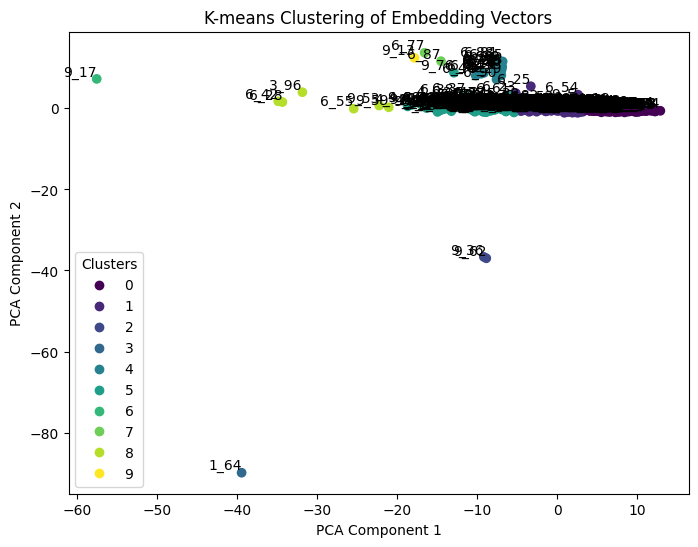

In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_matrix_scaled)

# Create a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=df['cluster'], cmap='viridis')

# Annotate each point with the filename
for i, file in enumerate(df['file']):
    plt.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], file[6:], fontsize=10, color='black', ha='right', va='bottom')

# Add labels and title
plt.title("K-means Clustering of Embedding Vectors")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Show the color legend for clusters
plt.legend(*scatter.legend_elements(), title="Clusters")

# Show the plot
plt.show()

In [30]:
def visualize_graph(G, title="Graph Visualization"):
    plt.figure(figsize=(8, 6))
    
    # Layout for better visualization
    pos = nx.spring_layout(G, seed=42)  

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color="lightblue", edgecolors="black")

    # Draw edges
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

    plt.title(title)
    plt.axis("off")  # Hide axes
    plt.show()

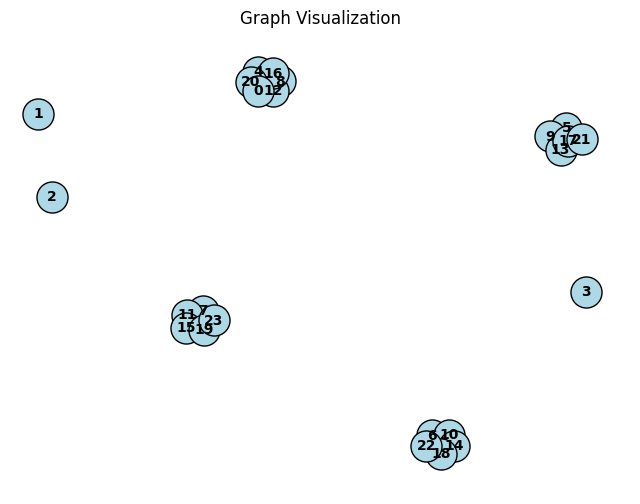

In [31]:
visualize_graph(fg_map["length5_42"])